Linear Regression Model Predicting Student Marks Based On The Hours Of Study

In [2]:
#Importing some important libraries for the model like (Numpy, Pandas, Matplotlib).
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

#Printing the version of these libraries.
print(np.__version__)
print(pd.__version__)

2.5.0
3.0.3


In [3]:
#Using pandas to import the data from the Excel file ("AvgStudyHour") and converting it to a one-dimension (1D) numpy array giving the name X.
X=pd.read_excel("AvgStudyHour.xlsx").to_numpy().flatten()
#Using pandas to import the data from the Excel file ("Marks") and converting it to a one-dimension (1D) numpy array giving the name y.
y=pd.read_excel("Marks.xlsx").to_numpy().flatten()

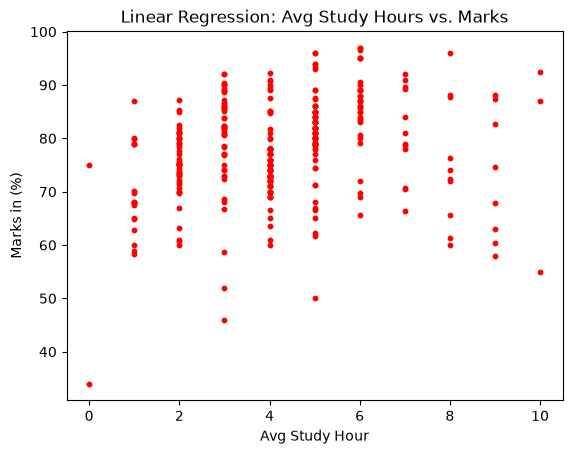

In [4]:
#Using matplotlib plotting a scatter plot of X and y, with the size of 10, color red.
plt.scatter(X, y, s=10, c='r')
#Using the .title() function of matplotlib giving the graph a title of ("Linear Regression: Avg Study Hours vs. Marks").
plt.title("Linear Regression: Avg Study Hours vs. Marks")
#Using the .xlabel() function of matplotlib giving the graph x-axis the name of ("Avg Study Hour").
plt.xlabel("Avg Study Hour")
#Using the .ylabel() function of matplotlib giving the graph y-axis the name of ("Marks in (%)")
plt.ylabel("Marks in (%)")
#Using the function named .show() showing the plotted graph
plt.show()

In [6]:
#Delaring weight as w to help the model to generalize better to unseen test data set also it help in preventing overfitting.
w=0.1
#The bias acts as the model's baseline anchor. It represents the predicted base score when all input features are zero, shifting the regression line vertically to properly fit the dataset.
b=0.1
#Delaring learning rate as learning_rate to control the step size during optimization a higher learning rate will speed up training but risk overshooting optimal value and a lower learning rate leads to slow convergence and requires more epochs, because of this we choose an optimal balance learning rate of 0.01.
learning_rate=0.01

In [7]:
#The Cost Function (Mean Squared Error) is simply the model's scoreboard. Its only job is to look at the current line and calculate exactly how many "points" it missed the real data by.
def compute_cost(X,y,w,b):
    #m is the total number of data points in are data set
    m=len(y)
    cost=0
    for i in range(m):
        # Using our current w and b, predict the Marks for every Age.
        fx=w*X[i]+b
        #Subtract the actual Marks from our predictions and add them after squaring them to see how far off we were.
        cost+=(fx-y[i])**2
    #Add up all the squared errors and divide by 'm' to get the Mean (Average) Squared Error.
    total_cost=(1/(2*m))*cost
    return total_cost

In [8]:
#The Gradients tell us which direction to step to get better. This calculates the slope of the error hill.
def gradient(X,y,w,b):
    dj_dw=0
    dj_db=0
    m=len(y)

    for i in range(m):
        #Calculate our current predictions based on the current line
        fx=w*X[i]+b
        #We multiply the errors by X (Age). If a large Age caused a large error, it means our weight (slope) is way off and needs a bigger adjustment.
        dj_dw+=(X[i]*(fx-y[i]))
        #We just take the average of all the raw errors.
        dj_db+=(fx-y[i])

    dj_db=dj_db/m
    dj_dw=dj_dw/m
    return dj_dw,dj_db

In [9]:
epochs = 2000
for epoch in range(epochs):
    #Which way should I adjust w and b to lower the error
    dj_dw, dj_db = gradient(X,y, w, b)

    #Update our parameters. We SUBTRACT the gradient because we want to go DOWN the error hill, not up. We multiply by learning_rate to ensure the step is small enough that we don't explode past the bottom.
    w = w - (learning_rate * dj_dw)
    b = b - (learning_rate * dj_db)

In [10]:
m = len(y)
predicted = np.zeros(m)

for i in range(m):
    predicted[i] = w * X[i] + b

Text(0, 0.5, 'Marks in (%)')

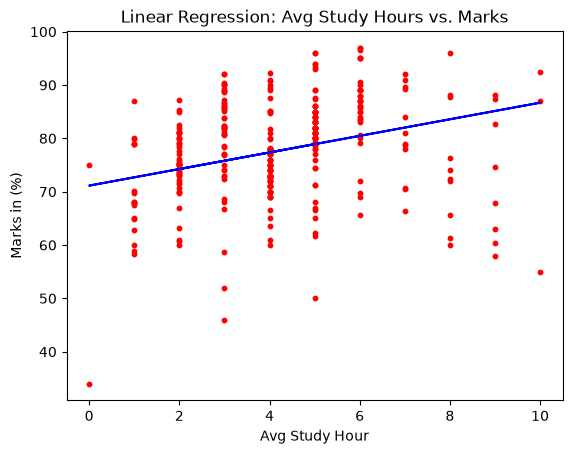

In [12]:
#Using matplotlib plotting a line plot of X and predicted,with color blue.
plt.plot(X, predicted, c='b')
#Using matplotlib plotting a scatter plot of X and y, with the size of 10, color red.
plt.scatter(X, y, s=10, c='r')
#Using the .title() function of matplotlib giving the graph a title of ("Linear Regression: Avg Study Hours vs. Marks").
plt.title('Linear Regression: Avg Study Hours vs. Marks')
#Using the .xlabel() function of matplotlib giving the graph x-axis the name of ("Avg Study Hour").
plt.xlabel('Avg Study Hour')
#Using the .ylabel() function of matplotlib giving the graph y-axis the name of ("Marks in (%)")
plt.ylabel('Marks in (%)')
#Using the function named .show() showing the plotted graph
plt.show()

In [88]:
#Taking input from the user the avg time in hours they study a day.
AvgStudyHour=int(input("Enter Avg Study Hour: "))
#Using the linear reg model finding the marks in (%) the user can get.
AvgMarks=w*AvgStudyHour+b
#Using the round() function rounding of the marks upto two decimal points.
RoundedAvgMark = round(AvgMarks, 2)
#Using the print() function print the marks of the user in percentage.
print("Your Marks in (%) is: ",RoundedAvgMark,"%")

Your Marks in (%) is:  71.14 %
